# 03 — Running the analysis that was fixed in advance

This notebook executes `ANALYSIS_PLAN.md` and nothing else. The plan was committed
before this file existed, so every choice that could have been made to favour a result —
which outcome, which test, which alpha, how the four blocks are handled — was already
closed when the first number appeared here.

The order below is the order the plan sets, and it matters: the manipulation check comes
before the primary test, because whether the podcast induced boredom decides what the
primary test is a test *of*. Sections are labelled confirmatory, secondary or exploratory
exactly as the plan labels them, and nothing is promoted between labels.

*Ноутбук исполняет `ANALYSIS_PLAN.md` и больше ничего. План закоммичен до того, как
появился этот файл, поэтому всякий выбор, которым можно было бы подыграть результату —
какой исход, какой тест, какая альфа, как обходиться с четырьмя блоками, — был закрыт
ещё до того, как здесь появилось первое число.*

*Порядок ниже задан планом, и он существен: проверка манипуляции идёт до первичного
теста, потому что от того, вызвал ли подкаст скуку, зависит, тестом ЧЕГО является
первичный тест. Разделы помечены как confirmatory, secondary или exploratory ровно так,
как их помечает план, и между метками ничего не переносится.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
import statsmodels.formula.api as smf

REPO = Path.cwd().parent
DER = REPO / "data" / "derived"
FIG = REPO / "figures"
RES = REPO / "results"
FIG.mkdir(exist_ok=True); RES.mkdir(exist_ok=True)

PRIMARY = "PeriodicPower"      # fixed by ANALYSIS_PLAN.md section 3
SECONDARY = "RemnantPower"     # section 7
ALPHA = 0.05                   # section 4
N_BOOT = 10_000
SEED = 20260907                # so the bootstrap interval is reproducible

In [2]:
data = pd.read_csv(DER / "analysis_long.csv")
print(data.shape)
data.head(3)

(104, 19)


,ID,session,period,condition,block,height,weight,boredom,state_pre,state_post,state_delta,flag_calibration,no_recording,PeriodicPower,RemnantPower,VisualWeight,rms_ap,rms_ml,rms_total
0,AN07IE11,A,1,HB,1,1.77,68,3.0,14,40,26,False,False,0.016358,0.042411,0.307419,0.381937,0.361750,0.540140
1,AN07IE11,A,1,HB,2,1.77,68,3.0,14,40,26,False,False,0.031991,0.045898,0.367774,0.465818,0.403897,0.658766
2,AN07IE11,A,1,HB,3,1.77,68,4.0,14,40,26,False,False,0.024861,0.072820,0.358578,0.508022,0.350741,0.718451


## Participant flow

The numbers the Methods section has to state, taken from the table rather than counted by
hand: who was recruited, who the QC removed, and who is left with a value in both
conditions. The last count is the one the confirmatory test runs on, because a
within-subject comparison needs both halves of the pair.

*Числа, которые должны быть названы в Methods, берутся из таблицы, а не считаются руками:
кто набран, кого убрал QC и у кого остались значения в обоих условиях. Последнее число —
то, на котором работает подтверждающий тест: внутрисубъектному сравнению нужны обе
половины пары.*

In [3]:
exc = pd.read_csv(DER / "qc_exclusions.csv")

blocks_present = (data.dropna(subset=[PRIMARY])
                      .groupby(["ID", "condition"]).size().unstack(fill_value=0))
blocks_present["complete"] = (blocks_present[["HB", "LB"]] == 4).all(axis=1)
blocks_present

condition,HB,LB,complete
ID,,,
AN07IE11,4,4,True
AN23BE15,4,4,True
BI20OE24,3,3,False
CA04TU11,4,4,True
CH08TU30,4,4,True
CH10AL22,4,4,True
CH11RE22,4,4,True
DI16UB31,4,4,True
DO11UB30,0,3,False


In [4]:
paired_ids = blocks_present[(blocks_present[["HB", "LB"]] > 0).all(axis=1)].index
complete_ids = blocks_present[blocks_present["complete"]].index

removed = exc[(exc["level"] == "participant") & (exc["action"] == "exclude")]["ID"].nunique()
flagged = exc[exc["action"] == "keep-and-report"]["ID"].nunique()

print("in the analysis table      ", data["ID"].nunique())
print("removed by QC              ", removed)
print("flagged, kept              ", flagged)
print("both conditions -> primary ", len(paired_ids))
print("all four blocks both sides ", len(complete_ids))

in the analysis table       13
removed by QC               1
flagged, kept               1
both conditions -> primary  12
all four blocks both sides  10


## Aggregation

The plan fixes the aggregation before the test: the four blocks are averaged within each
participant × condition, over whatever blocks are available. `.groupby().mean()` skips
missing values by default, which is what the plan's clarification asks for, and
`.unstack()` puts the two conditions side by side so the difference is one subtraction.

Everything downstream works from this paired table, so it is printed in full — twelve
rows is small enough that the reader can check any single number against the long table.

*План фиксирует агрегацию до теста: четыре блока усредняются внутри участник × условие по
тем блокам, что есть. `.groupby().mean()` по умолчанию пропускает пропуски — ровно то,
чего требует уточнение к плану, — а `.unstack()` ставит два условия рядом, и разность
берётся одним вычитанием.*

*Всё дальнейшее считается от этой парной таблицы, поэтому она печатается целиком:
двенадцать строк — достаточно мало, чтобы читатель мог сверить любое число с длинной
таблицей.*

In [5]:
primary_pairs = data.groupby(["ID", "condition"])[PRIMARY].mean().unstack()

# The mean skips missing blocks; dropna then leaves only participants with both conditions.
primary_pairs = primary_pairs.dropna()
primary_pairs["diff"] = primary_pairs["HB"] - primary_pairs["LB"]

primary_pairs.round(5)

condition,HB,LB,diff
ID,,,
AN07IE11,0.02388,0.04930,-0.02542
AN23BE15,0.04617,0.04458,0.00159
BI20OE24,0.02962,0.01868,0.01094
CA04TU11,0.03605,0.06195,-0.02590
CH08TU30,0.02063,0.03611,-0.01548
CH10AL22,0.03807,0.07101,-0.03294
CH11RE22,0.00787,0.00879,-0.00092
DI16UB31,0.02802,0.02819,-0.00016
EL30AD28,0.03037,0.00836,0.02200


## The four numbers every test reports

The plan asks the same four things of every confirmatory test: an exact p-value, the
median and range of the differences, a rank-biserial effect size and a bootstrap
interval for the median. The same handful of lines therefore appears in each section
below, with only the table it works on changing.

`method="exact"` is available because n is small and the differences contain no ties, so
the p-value is the true permutation probability rather than a normal approximation. The
rank-biserial correlation is the signed-rank statistic rescaled to −1…1: the share of the
total rank mass on the positive side minus the share on the negative side. The interval is
a percentile bootstrap of the median difference, seeded so it comes out the same on a
re-run.

*План требует от каждого подтверждающего теста одни и те же четыре вещи: точное
p-значение, медиану и размах разностей, ранго-бисериальный размер эффекта и
бутстрэп-интервал для медианы. Поэтому одни и те же несколько строк повторяются в каждом
разделе ниже — меняется только таблица, с которой они работают.*

*`method="exact"` доступен, потому что n мало и в разностях нет связок: p-значение
получается истинной перестановочной вероятностью, а не нормальным приближением.
Ранго-бисериальная корреляция — статистика знаковых рангов, растянутая на −1…1: доля
ранговой массы на положительной стороне минус доля на отрицательной. Интервал —
процентильный бутстрэп медианы разности с фиксированным зерном, чтобы при повторном
запуске получалось то же самое.*

## Manipulation check — reported first

Whether the high-boredom podcast induced more boredom than the low-boredom one. The
outcome is the change in the eight-item state boredom scale across a session
(`state_delta` = post − pre), compared between conditions within participant. Same test as
the primary outcome, same alpha.

The plan states in advance what happens either way: if this check fails, the primary test
is still run and reported, and it becomes a test of the effect of the *podcast condition*
rather than of *boredom*. No participant is removed to make the check pass.

*Вызвал ли «скучный» подкаст больше скуки, чем «нескучный». Исход — изменение
восьмипунктовой шкалы состояния скуки за сессию (`state_delta` = после − до), сравнивается
между условиями внутри участника. Тест и альфа те же, что у первичного исхода.*

*План заранее говорит, что будет в любом случае: если проверка не пройдёт, первичный тест
всё равно запускается и отчитывается, но становится тестом эффекта УСЛОВИЯ, а не СКУКИ.
Ни один участник не удаляется ради прохождения проверки.*

In [6]:
state = data.groupby(["ID", "condition"])["state_delta"].mean().unstack().dropna()
state["diff"] = state["HB"] - state["LB"]
state.round(1)

condition,HB,LB,diff
ID,,,
AN07IE11,26.0,-4.0,30.0
AN23BE15,14.0,-11.0,25.0
BI20OE24,20.0,6.0,14.0
CA04TU11,1.0,-1.0,2.0
CH08TU30,26.0,4.0,22.0
CH10AL22,9.0,23.0,-14.0
CH11RE22,12.0,2.0,10.0
DI16UB31,6.0,1.0,5.0
DO11UB30,7.0,2.0,5.0


In [7]:
results = []

d = state["diff"]
res = stats.wilcoxon(state["HB"], state["LB"], alternative="two-sided", method="exact")

# Rank-biserial correlation: rank mass on the positive side minus the negative side.
nz = d[d != 0]
ranks = stats.rankdata(nz.abs())
r_rb = (ranks[nz.values > 0].sum() - ranks[nz.values < 0].sum()) / ranks.sum()

# Percentile bootstrap of the median difference, fixed seed.
rng = np.random.default_rng(SEED)
boot = np.median(rng.choice(d.values, size=(N_BOOT, len(d))), axis=1)
lo, hi = np.percentile(boot, [2.5, 97.5])

results.append({"test": "Manipulation check: state boredom change (HB - LB)", "n": len(d), "W": res.statistic, "p": res.pvalue,
                 "median_diff": d.median(), "min_diff": d.min(), "max_diff": d.max(),
                 "rank_biserial": r_rb, "ci_low": lo, "ci_high": hi})

print(f"n = {len(d)}   W = {res.statistic:.1f}   p = {res.pvalue:.4f}"
      f"   {'<' if res.pvalue < ALPHA else '>='} alpha = {ALPHA}")
print(f"median difference (HB - LB) = {d.median():+.2f}   "
      f"[{d.min():+.2f}, {d.max():+.2f}]")
print(f"95% bootstrap CI of the median = [{lo:+.2f}, {hi:+.2f}]")
print(f"rank-biserial r = {r_rb:+.3f}")

n = 13   W = 7.5   p = 0.0122   < alpha = 0.05
median difference (HB - LB) = +10.00   [-14.00, +30.00]
95% bootstrap CI of the median = [+5.00, +21.00]
rank-biserial r = +0.808


## Confirmatory test — the answer to the research question

Periodic power, anterior-posterior, averaged over blocks, HB against LB. Wilcoxon
signed-rank, two-sided, alpha .05. This is the one test the plan designates as
confirmatory, and its result is the answer regardless of anything computed below it.

*Periodic power, передне-задний, усреднён по блокам, HB против LB. Wilcoxon signed-rank,
двусторонний, альфа .05. Это единственный тест, который план объявляет подтверждающим, и
его результат является ответом независимо от всего, что посчитано ниже.*

In [8]:
d = primary_pairs["diff"]
res = stats.wilcoxon(primary_pairs["HB"], primary_pairs["LB"], alternative="two-sided", method="exact")

# Rank-biserial correlation: rank mass on the positive side minus the negative side.
nz = d[d != 0]
ranks = stats.rankdata(nz.abs())
r_rb = (ranks[nz.values > 0].sum() - ranks[nz.values < 0].sum()) / ranks.sum()

# Percentile bootstrap of the median difference, fixed seed.
rng = np.random.default_rng(SEED)
boot = np.median(rng.choice(d.values, size=(N_BOOT, len(d))), axis=1)
lo, hi = np.percentile(boot, [2.5, 97.5])

results.append({"test": "PRIMARY: PeriodicPower (HB - LB)", "n": len(d), "W": res.statistic, "p": res.pvalue,
                 "median_diff": d.median(), "min_diff": d.min(), "max_diff": d.max(),
                 "rank_biserial": r_rb, "ci_low": lo, "ci_high": hi})

print(f"n = {len(d)}   W = {res.statistic:.1f}   p = {res.pvalue:.4f}"
      f"   {'<' if res.pvalue < ALPHA else '>='} alpha = {ALPHA}")
print(f"median difference (HB - LB) = {d.median():+.5f}   "
      f"[{d.min():+.5f}, {d.max():+.5f}]")
print(f"95% bootstrap CI of the median = [{lo:+.5f}, {hi:+.5f}]")
print(f"rank-biserial r = {r_rb:+.3f}")

n = 12   W = 21.0   p = 0.1763   >= alpha = 0.05
median difference (HB - LB) = -0.00611   [-0.03294, +0.02200]
95% bootstrap CI of the median = [-0.02045, +0.00145]
rank-biserial r = -0.462


### Sensitivity, not a second chance

Two robustness checks the plan named in advance: the paired *t*-test on the same twelve
differences, and the same signed-rank test restricted to participants who have all four
blocks in both conditions. Neither can replace the result above — they are reported so a
reader can see whether it depends on the choice of test or on the participants with
incomplete blocks.

*Две проверки устойчивости, названные планом заранее: парный t-тест на тех же двенадцати
разностях и тот же ранговый тест на участниках, у которых все четыре блока есть в обоих
условиях. Ни одна не заменяет результат выше — они отчитываются, чтобы читатель видел,
зависит ли он от выбора теста и от участников с неполными блоками.*

In [9]:
t = stats.ttest_rel(primary_pairs["HB"], primary_pairs["LB"])
d_z = primary_pairs["diff"].mean() / primary_pairs["diff"].std(ddof=1)
print(f"paired t-test    t({len(primary_pairs) - 1}) = {t.statistic:+.3f}"
      f"   p = {t.pvalue:.4f}   d_z = {d_z:+.3f}\n")

complete_pairs = primary_pairs.loc[primary_pairs.index.intersection(complete_ids)]

d = complete_pairs["diff"]
res = stats.wilcoxon(complete_pairs["HB"], complete_pairs["LB"], alternative="two-sided", method="exact")

# Rank-biserial correlation: rank mass on the positive side minus the negative side.
nz = d[d != 0]
ranks = stats.rankdata(nz.abs())
r_rb = (ranks[nz.values > 0].sum() - ranks[nz.values < 0].sum()) / ranks.sum()

# Percentile bootstrap of the median difference, fixed seed.
rng = np.random.default_rng(SEED)
boot = np.median(rng.choice(d.values, size=(N_BOOT, len(d))), axis=1)
lo, hi = np.percentile(boot, [2.5, 97.5])

results.append({"test": "Sensitivity: PeriodicPower, complete blocks only", "n": len(d), "W": res.statistic, "p": res.pvalue,
                 "median_diff": d.median(), "min_diff": d.min(), "max_diff": d.max(),
                 "rank_biserial": r_rb, "ci_low": lo, "ci_high": hi})

print(f"n = {len(d)}   W = {res.statistic:.1f}   p = {res.pvalue:.4f}"
      f"   {'<' if res.pvalue < ALPHA else '>='} alpha = {ALPHA}")
print(f"median difference (HB - LB) = {d.median():+.5f}   "
      f"[{d.min():+.5f}, {d.max():+.5f}]")
print(f"95% bootstrap CI of the median = [{lo:+.5f}, {hi:+.5f}]")
print(f"rank-biserial r = {r_rb:+.3f}")

paired t-test    t(11) = -1.599   p = 0.1382   d_z = -0.461

n = 10   W = 14.0   p = 0.1934   >= alpha = 0.05
median difference (HB - LB) = -0.00719   [-0.03294, +0.02200]
95% bootstrap CI of the median = [-0.02542, +0.00132]
rank-biserial r = -0.491


## Secondary 1 — does an effect build up over the session?

The averaging above deliberately throws away the block dimension. This model puts it back:
a linear mixed model on the trial-level rows with `condition`, `block` and their
interaction as fixed effects, `period` as a covariate for session order, and a random
intercept per participant. The outcome enters as its natural logarithm, as the plan's
clarification fixes.

The interaction term is the one that answers the question in the heading — whether the gap
between conditions widens across the four blocks. This is a secondary analysis: its
p-value is reported as secondary and no correction is applied or claimed.

*Усреднение выше намеренно выбрасывает измерение блоков. Эта модель возвращает его:
линейная смешанная модель на строках уровня пробы с `condition`, `block` и их
взаимодействием как фиксированными эффектами, `period` как ковариатой порядка сессий и
случайным свободным членом на участника. Исход входит натуральным логарифмом, как
фиксирует уточнение к плану.*

*На вопрос в заголовке отвечает именно член взаимодействия — расходятся ли условия по мере
прохождения четырёх блоков. Это вторичный анализ: его p-значение отчитывается как
вторичное, поправка не применяется и не заявляется.*

In [10]:
trials = data.dropna(subset=[PRIMARY]).copy()
trials["log_outcome"] = np.log(trials[PRIMARY])
trials["condition"] = pd.Categorical(trials["condition"], categories=["LB", "HB"])
print("rows:", len(trials), "| participants:", trials["ID"].nunique())

rows: 96 | participants: 13


In [11]:
model = smf.mixedlm("log_outcome ~ condition * block + period", trials, groups=trials["ID"]).fit()
print(model.summary().tables[1])

                        Coef. Std.Err.        z  P>|z|  [0.025  0.975]
Intercept              -3.912    0.286  -13.694  0.000  -4.472  -3.352
condition[T.HB]        -0.410    0.257   -1.594  0.111  -0.915   0.094
block                   0.059    0.065    0.901  0.368  -0.069   0.187
condition[T.HB]:block   0.125    0.092    1.359  0.174  -0.055   0.305
period                  0.153    0.104    1.471  0.141  -0.051   0.358
Group Var               0.260    0.270                                


## Secondary 2 — remnant power

The other deterministic parameter: sway power at the frequencies the visual stimulus does
*not* occupy. It speaks to overall sway rather than to the response to the scene, so it
separates a change specific to visual following from a change in how much the participant
swayed at all. Same test as the primary outcome.

*Второй детерминированный параметр: мощность колебаний на частотах, которые зрительный
стимул НЕ занимает. Он говорит об общем раскачивании, а не об ответе на сцену, и потому
отделяет изменение, специфичное для следования за зрительным стимулом, от изменения того,
насколько участник раскачивался вообще. Тест тот же, что у первичного исхода.*

In [12]:
remnant_pairs = data.groupby(["ID", "condition"])[SECONDARY].mean().unstack().dropna()
remnant_pairs["diff"] = remnant_pairs["HB"] - remnant_pairs["LB"]

d = remnant_pairs["diff"]
res = stats.wilcoxon(remnant_pairs["HB"], remnant_pairs["LB"], alternative="two-sided", method="exact")

# Rank-biserial correlation: rank mass on the positive side minus the negative side.
nz = d[d != 0]
ranks = stats.rankdata(nz.abs())
r_rb = (ranks[nz.values > 0].sum() - ranks[nz.values < 0].sum()) / ranks.sum()

# Percentile bootstrap of the median difference, fixed seed.
rng = np.random.default_rng(SEED)
boot = np.median(rng.choice(d.values, size=(N_BOOT, len(d))), axis=1)
lo, hi = np.percentile(boot, [2.5, 97.5])

results.append({"test": "SECONDARY: RemnantPower (HB - LB)", "n": len(d), "W": res.statistic, "p": res.pvalue,
                 "median_diff": d.median(), "min_diff": d.min(), "max_diff": d.max(),
                 "rank_biserial": r_rb, "ci_low": lo, "ci_high": hi})

print(f"n = {len(d)}   W = {res.statistic:.1f}   p = {res.pvalue:.4f}"
      f"   {'<' if res.pvalue < ALPHA else '>='} alpha = {ALPHA}")
print(f"median difference (HB - LB) = {d.median():+.5f}   "
      f"[{d.min():+.5f}, {d.max():+.5f}]")
print(f"95% bootstrap CI of the median = [{lo:+.5f}, {hi:+.5f}]")
print(f"rank-biserial r = {r_rb:+.3f}")

n = 12   W = 35.0   p = 0.7910   >= alpha = 0.05
median difference (HB - LB) = -0.00468   [-0.06633, +0.06849]
95% bootstrap CI of the median = [-0.03435, +0.02866]
rank-biserial r = -0.103


## Exploratory — the rating instead of the condition

Everything from here is exploratory and is reported as such: no p-value below is presented
as a finding.

The condition is what was manipulated, but the 0–10 rating spoken after each block is what
the participant actually felt, and the two need not coincide. Regressing the outcome on the
rating rather than on the condition uses the within-session variation the condition
contrast discards. It is exploratory because the plan did not name it as a test, and
because the rating is not randomised — a participant who is bored may differ from one who
is not in ways the design does not control.

*Всё дальше — поисковое и отчитывается как поисковое: ни одно p-значение ниже не
подаётся как находка.*

*Условие — это то, чем манипулировали, но оценка 0–10, произнесённая после каждого блока, —
это то, что участник действительно чувствовал, и одно с другим совпадать не обязано.
Регрессия исхода на оценку, а не на условие, использует внутрисессионную вариацию, которую
контраст условий выбрасывает. Это поисковый анализ, потому что план не называл его тестом
и потому что оценка не рандомизирована: скучающий участник может отличаться от нескучающего
так, как дизайн не контролирует.*

In [13]:
rated = trials.dropna(subset=["boredom"])
explore = smf.mixedlm("log_outcome ~ boredom + period", rated, groups=rated["ID"]).fit()
print("rows:", len(rated))
print(explore.summary().tables[1])

rows: 92
            Coef. Std.Err.        z  P>|z|  [0.025  0.975]
Intercept  -3.944    0.222  -17.730  0.000  -4.381  -3.508
boredom     0.065    0.029    2.262  0.024   0.009   0.122
period      0.110    0.114    0.959  0.338  -0.115   0.334
Group Var   0.257    0.266                                


### A confound, checked after the fact

The model above was written before it was run. This one was added **after** seeing its
output, and is recorded that way rather than quietly folded in.

The spoken rating climbs across the four blocks of a session, and the outcome drifts across
blocks too, so a slope on the rating alone cannot be separated from time on task. Adding
`block` to the same model is the minimum test of that: if the rating carries anything beyond
elapsed time, its coefficient should survive the adjustment. The mean rating per block is
printed first, so the reader can see the drift the adjustment is for.

*Модель выше была написана до запуска. Эта добавлена ПОСЛЕ того, как её вывод был увиден, и
записана именно так, а не тихо подмешана.*

*Произносимая оценка растёт по четырём блокам сессии, и исход по блокам тоже дрейфует, —
значит, наклон по одной оценке неотделим от времени под нагрузкой. Добавление `block` в ту
же модель — минимальная проверка этого: если оценка несёт что-то сверх прошедшего времени,
её коэффициент должен пережить поправку. Сначала печатается средняя оценка по блокам, чтобы
читатель видел тот дрейф, ради которого делается поправка.*

In [14]:
print(rated.groupby("block")["boredom"].mean().round(2).to_string())
adjusted = smf.mixedlm("log_outcome ~ boredom + block + period", rated, groups=rated["ID"]).fit()
print()
print(adjusted.summary().tables[1])

block
1    2.14
2    2.92
3    3.29
4    4.09

            Coef. Std.Err.        z  P>|z|  [0.025  0.975]
Intercept  -4.154    0.251  -16.571  0.000  -4.646  -3.663
boredom     0.046    0.030    1.521  0.128  -0.013   0.106
block       0.092    0.051    1.803  0.071  -0.008   0.193
period      0.135    0.114    1.190  0.234  -0.087   0.358
Group Var   0.269    0.279                                


## The table and the figure

One results table, written to `results/confirmatory_tests.csv`, holding every signed-rank
test run above with its n, statistic, exact p-value, effect size and interval — so the
table in the paper is generated rather than retyped.

One figure with two panels, drawn from the paired tables: the manipulation check on the
left, the primary outcome on the right. Each participant is one line joining their two
conditions, because at this sample size a bar chart with error bars would hide the twelve
observations it is drawn from, and the within-subject pairing is the whole design. The
median is drawn on top; the conditions are separated by position, not by colour, so the
figure survives being printed in greyscale.

*Одна таблица результатов, пишется в `results/confirmatory_tests.csv`, содержит каждый
ранговый тест выше с его n, статистикой, точным p, размером эффекта и интервалом, — чтобы
таблица в статье генерировалась, а не перенабиралась.*

*Один рисунок из двух панелей по парным таблицам: слева проверка манипуляции, справа
первичный исход. Каждый участник — одна линия, соединяющая его два условия: при таком
размере выборки столбики с усами спрятали бы те двенадцать наблюдений, из которых они
нарисованы, а внутрисубъектная парность — это и есть весь дизайн. Медиана рисуется сверху;
условия разделены положением, а не цветом, поэтому рисунок переживает печать в оттенках
серого.*

In [15]:
table = pd.DataFrame(results)[
    ["test", "n", "W", "p", "median_diff", "min_diff", "max_diff", "rank_biserial", "ci_low", "ci_high"]
]
table.to_csv(RES / "confirmatory_tests.csv", index=False)
table.round(4)

,test,n,W,p,median_diff,min_diff,max_diff,rank_biserial,ci_low,ci_high
0,Manipulation check: state boredom change (HB -...,13,7.5,0.0122,10.0000,-14.0000,30.0000,0.8077,5.0000,21.0000
1,PRIMARY: PeriodicPower (HB - LB),12,21.0,0.1763,-0.0061,-0.0329,0.0220,-0.4615,-0.0204,0.0015
2,"Sensitivity: PeriodicPower, complete blocks only",10,14.0,0.1934,-0.0072,-0.0329,0.0220,-0.4909,-0.0254,0.0013
3,SECONDARY: RemnantPower (HB - LB),12,35.0,0.7910,-0.0047,-0.0663,0.0685,-0.1026,-0.0344,0.0287


-> paired_outcomes.png


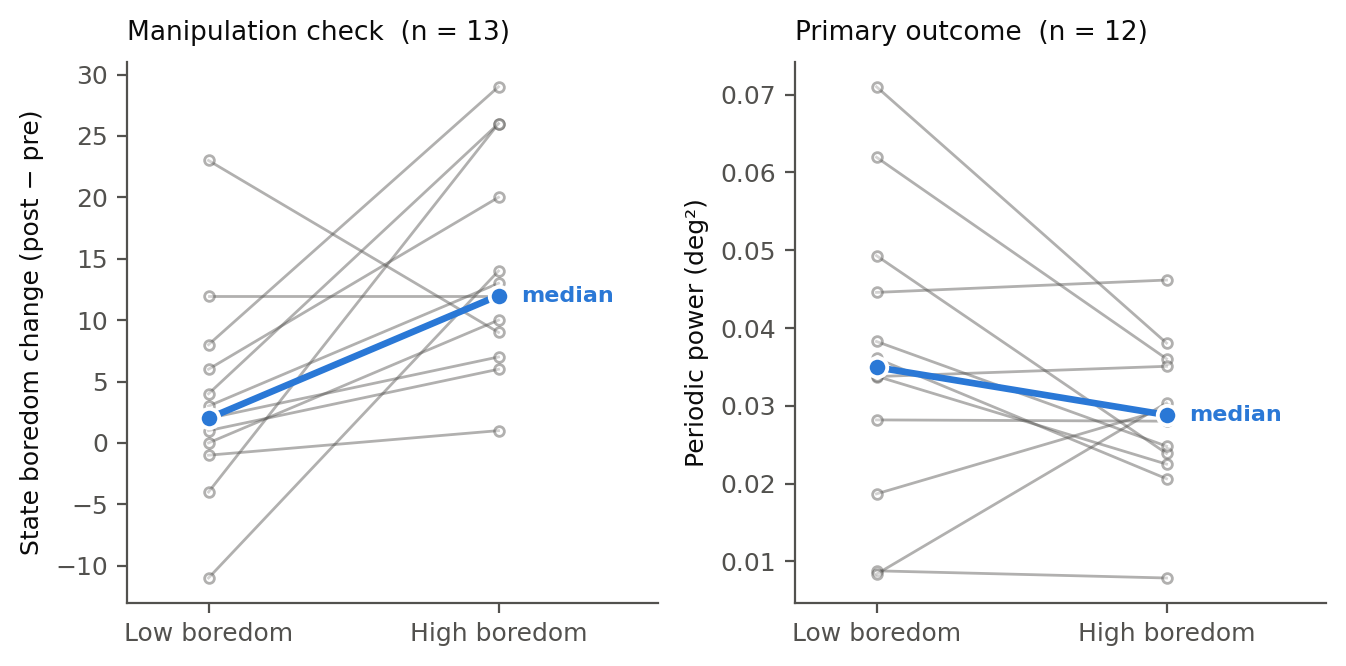

In [16]:
INK, MUTED, ACCENT = "#0b0b0b", "#52514e", "#2a78d6"
plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "text.color": INK, "axes.labelcolor": INK,
                     "xtick.color": MUTED, "ytick.color": MUTED, "figure.dpi": 200})

panels = [(state, "State boredom change (post − pre)", "Manipulation check"),
          (primary_pairs, "Periodic power (deg²)", "Primary outcome")]

fig, axes = plt.subplots(1, 2, figsize=(6.8, 3.4))
for ax, (pairs, ylabel, title) in zip(axes, panels):
    for _, r in pairs.iterrows():
        ax.plot([0, 1], [r["LB"], r["HB"]], color=MUTED, alpha=0.45, lw=1,
                marker="o", ms=3.5, mfc="white", mec=MUTED, mew=1, zorder=2)
    med = [pairs["LB"].median(), pairs["HB"].median()]
    ax.plot([0, 1], med, color=ACCENT, lw=2.4, marker="o", ms=7, mfc=ACCENT,
            mec="white", mew=1.4, zorder=3)
    # Direct label instead of a legend box, so nothing sits on top of the data.
    ax.annotate("median", xy=(1, med[1]), xytext=(8, 0), textcoords="offset points",
                va="center", ha="left", fontsize=8, color=ACCENT, fontweight="bold")
    ax.set_xticks([0, 1], ["Low boredom", "High boredom"])
    ax.set_xlim(-0.28, 1.55)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{title}  (n = {len(pairs)})", loc="left", fontsize=9.5, color=INK, pad=8)

fig.tight_layout()
fig.savefig(FIG / "paired_outcomes.png", bbox_inches="tight")
print("->", (FIG / "paired_outcomes.png").name)
plt.show()

## What was run, and what was not

Four signed-rank tests exist above: one manipulation check, one confirmatory test, one
sensitivity version of it, and one secondary outcome. Three mixed models: one secondary and
two exploratory, the second of which is marked as having been added after seeing the first.
That is the whole list, it matches `ANALYSIS_PLAN.md`, and nothing was run and
discarded — a test that had been tried and left out would not appear in this notebook, but
it would appear in its git history, which is why the plan was committed first.

*Выше существуют четыре ранговых теста: одна проверка манипуляции, один подтверждающий
тест, одна его версия для проверки устойчивости и один вторичный исход. Три смешанные
модели: одна вторичная и две поисковые, причём вторая помечена как добавленная после того,
как была увидена первая. Это весь список, он совпадает с
`ANALYSIS_PLAN.md`, и ничего не запускалось и не выбрасывалось — тест, который попробовали
и не включили, не появился бы в этом ноутбуке, но появился бы в истории git, ради чего план
и коммитился первым.*